<a href="https://colab.research.google.com/github/neeyatlotlikar/me_fy_project/blob/dev/ADF_single_user_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Select a suitable user

In [1]:
!pip install pandas numpy scipy gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.3 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/ME_PROJECT/Implementation

/content/drive/MyDrive/ME_PROJECT/Implementation


In [5]:
model_save_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/models"

In [6]:
!pip install lightfm-next -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 7.3 MB/s eta 0:00:00


In [7]:
USER_INDEX = 1

In [8]:
import pandas as pd

behaviors_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/data/MINDsmall_train/behaviors.tsv"

# Column names from MIND documentation
columns = [
    "impression_id",
    "user_id",
    "time",
    "history",
    "impressions"
]

# Load dataset
behaviors = pd.read_csv(
    behaviors_path,
    sep="\t",
    names=columns
)

# Show dataset shape
print("Dataset shape:", behaviors.shape)

# Show first rows
behaviors.head()

Dataset shape: (156965, 5)


,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [9]:
clicked_data = []

for _, row in behaviors.iterrows():

    user = row["user_id"]
    impressions = row["impressions"].split()

    for imp in impressions:
        news_id, label = imp.split("-")

        if label == "1":
            clicked_data.append((user, news_id))

# Convert to dataframe
clicks_df = pd.DataFrame(clicked_data, columns=["user_id", "news_id"])

print("Total click interactions:", len(clicks_df))
clicks_df.head()

Total click interactions: 236344


,user_id,news_id
0,U13740,N55689
1,U91836,N17059
2,U73700,N23814
3,U34670,N49685
4,U8125,N8400


In [10]:
clicks_df.describe()

,user_id,news_id
count,236344,236344
unique,50000,7713
top,U53220,N55689
freq,129,4316


In [11]:
selected_user = behaviors.iloc[USER_INDEX]

In [12]:
behaviors.loc[behaviors['user_id'] == selected_user.user_id]

,impression_id,user_id,time,history,impressions
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
6672,6673,U91836,11/9/2019 6:21:10 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N26721-0 N6658-0 N23548-0 N13423-0 N18870-0 N3...
10937,10938,U91836,11/10/2019 5:37:46 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N40110-0 N41224-0 N55489-0 N23085-0 N28820-1 N...
20675,20676,U91836,11/9/2019 5:28:51 AM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N46057-0 N29017-0 N7128-0 N18378-0 N27845-0 N5...
45064,45065,U91836,11/13/2019 8:06:29 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N14029-1 N4404-0 N51048-0 N49712-0 N36261-0 N3...
57350,57351,U91836,11/11/2019 4:50:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N46029-0 N46526-0 N54489-1 N8191-0 N53585-0 N2...
66721,66722,U91836,11/12/2019 3:21:36 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N39317-0 N40380-0 N261-0 N20678-0 N40839-0 N49...
77119,77120,U91836,11/12/2019 7:21:20 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N14592-0 N39317-0 N20915-0 N62386-0 N19423-0 N...
84986,84987,U91836,11/12/2019 5:20:00 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N33885-1 N20495-0
97244,97245,U91836,11/10/2019 5:43:35 AM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N61022-0 N9473-0 N12589-0 N54595-0 N42346-0 N4...


In [13]:
clicks_df.loc[clicks_df['user_id'] == selected_user.user_id]

,user_id,news_id
1,U91836,N17059
10014,U91836,N26365
16349,U91836,N28820
30918,U91836,N22816
67536,U91836,N14029
86207,U91836,N54489
100422,U91836,N33212
115975,U91836,N27601
127805,U91836,N33885
146262,U91836,N18572


In [14]:
# Path to news metadata
news_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/data/MINDsmall_train/news.tsv"

news_columns = [
    "news_id",
    "category",
    "subcategory",
    "title",
    "abstract",
    "url",
    "title_entities",
    "abstract_entities"
]

news_df = pd.read_csv(
    news_path,
    sep="\t",
    names=news_columns
)

print("News dataset shape:", news_df.shape)

news_df.head()

News dataset shape: (51282, 8)


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


User's click data to display. Try to select all of this user's news where he clicked and display a few for intuition.

# News Data prep

In [15]:
import joblib
# load saved news_cluster_map
news_cluster_map = joblib.load(f'{model_save_path}/news_cluster_map.joblib')

In [16]:
# Check cluster distribution
import collections

cluster_counts = collections.Counter(news_cluster_map.values())

print("Top 10 cluster sizes:")
for cluster, count in cluster_counts.most_common(10):
    print(f"Cluster {cluster}: {count} items")

Top 10 cluster sizes:
Cluster 27: 46767 items
Cluster -1: 2053 items
Cluster 23: 261 items
Cluster 6: 199 items
Cluster 2: 174 items
Cluster 14: 135 items
Cluster 19: 126 items
Cluster 25: 102 items
Cluster 21: 95 items
Cluster 24: 91 items


In [17]:
news_cluster_df = news_df[['news_id', 'category', 'subcategory']].copy()
news_cluster_df['cluster'] = news_cluster_df['news_id'].map(news_cluster_map)

print("News cluster dataframe shape:", news_cluster_df.shape)
news_cluster_df.head()

News cluster dataframe shape: (51282, 4)


,news_id,category,subcategory,cluster
0,N55528,lifestyle,lifestyleroyals,27
1,N19639,health,weightloss,27
2,N61837,news,newsworld,27
3,N53526,health,voices,27
4,N38324,health,medical,27


In [ ]:
# @title saving the created dataframe
joblib.dump(news_cluster_df, f'{model_save_path}/news_cluster_df.joblib')

['/content/drive/MyDrive/ME_PROJECT/Implementation/models/news_cluster_df.joblib']

In [18]:
user_click_hist = list(clicks_df.loc[clicks_df['user_id'] == selected_user.user_id]['news_id'])

In [19]:
news_cluster_df.loc[news_cluster_df['news_id'].isin(user_click_hist)]

,news_id,category,subcategory,cluster
32186,N17059,finance,finance-companies,27
33649,N33885,finance,finance-companies,27
34303,N27601,news,newsworld,27
34634,N54489,news,newsus,27
35166,N14029,lifestyle,lifestylebuzz,27
35956,N37190,travel,travelnews,27
36053,N34520,video,viral,27
39716,N18572,news,newsworld,27
40890,N26365,news,newscrime,-1
43358,N7325,news,newscrime,27


In [20]:
# Load saved model
model = joblib.load(f'{model_save_path}/lightfm_mind.joblib')


In [21]:
from lightfm.data import Dataset

# Create LightFM dataset object
dataset = Dataset()

# Fit dataset with users and items
dataset.fit(
    users=clicks_df["user_id"].unique(),
    items=clicks_df["news_id"].unique()
)

# Build interaction matrix
(interactions, weights) = dataset.build_interactions(
    [(row.user_id, row.news_id) for row in clicks_df.itertuples()]
)

print("Interaction matrix shape:", interactions.shape)
print("Total interactions:", interactions.nnz)

Interaction matrix shape: (50000, 7713)
Total interactions: 236344


In [22]:
# @title MUST RUN as inv_item_map variable is needed
import numpy as np

# Get mapping from dataset
user_id_map, user_feature_map, item_id_map, item_feature_map = dataset.mapping()

# Reverse mapping (index → original ID)
inv_item_map = {v: k for k, v in item_id_map.items()}

# Choose a sample user
# Globally set as USER_INDEX

# Predict scores for all items
scores = model.predict(USER_INDEX, np.arange(interactions.shape[1]))

# Get top 10 items
top_items = np.argsort(-scores)[:10]

print("Top 10 recommended news articles:")
recs = []
for item in top_items:
    print(
        inv_item_map[item],
        scores[item],
        news_cluster_map.get(inv_item_map[item], "NA")
    )
    recs.append(inv_item_map[item])

Top 10 recommended news articles:
N41881 2.008572 27
N49279 1.8270637 27
N54489 1.7760123 27
N55689 1.6895533 27
N35729 1.621306 27
N49685 1.6145861 27
N56214 1.5631293 27
N33619 1.5333945 27
N53585 1.5311542 -1
N33885 1.5116494 27


In [23]:
news_cluster_df.loc[news_cluster_df['news_id'].isin(recs)]

,news_id,category,subcategory,cluster
33649,N33885,finance,finance-companies,27
33899,N55689,sports,football_nfl,27
34599,N41881,tv,tv-celebrity,27
34634,N54489,news,newsus,27
41550,N33619,news,newsus,27
42879,N56214,weather,weathertopstories,27
45974,N53585,tv,tvnews,-1
50365,N49279,music,musicnews,27
50688,N35729,news,newsus,27
50714,N49685,music,music-celebrity,27


# ADF Setup

## AD

In [24]:
def ad_rerank_greedy(user_index, model, interactions, inv_item_map,
                     news_cluster_map, alpha=0.7, top_k=10):

    scores = model.predict(user_index, np.arange(interactions.shape[1]))
    ranked_items = list(np.argsort(-scores))

    selected_items = []
    cluster_counts = {}

    for _ in range(top_k):

        best_item = None
        best_score = -np.inf
        best_cluster = None

        for item in ranked_items:

            news_id = inv_item_map[item]
            cluster = news_cluster_map.get(news_id, -1)

            penalty = cluster_counts.get(cluster, 0)

            final_score = alpha * scores[item] - (1 - alpha) * penalty

            if final_score > best_score:
                best_score = final_score
                best_item = item
                best_cluster = cluster

        # add best item
        selected_items.append((best_item, best_score, best_cluster))

        # update cluster counts
        cluster_counts[best_cluster] = cluster_counts.get(best_cluster, 0) + 1

        # remove selected item
        ranked_items.remove(best_item)

    return selected_items

In [25]:
# Test for one user
ad_results = ad_rerank_greedy(
    user_index=0,
    model=model,
    interactions=interactions,
    inv_item_map=inv_item_map,
    news_cluster_map=news_cluster_map,
    alpha=0.7,
    top_k=10
)

print("AD (Greedy) recommendations:")
recs_ad = []
print("news_id", "Score", "Cluster")
for item, score, cluster in ad_results:
    print(inv_item_map[item], score, cluster)
    recs_ad.append(inv_item_map[item])

AD (Greedy) recommendations:
news_id Score Cluster
N55689 1.569356 27
N53585 1.163294 -1
N63970 1.0724039 27
N35729 0.6930951 27
N42634 0.64560354 23
N61145 0.543513 2
N45523 0.4363941 -1
N47061 0.35077643 27
N7809 0.33729428 15
N7754 0.31004918 8


In [26]:
news_cluster_df.loc[news_cluster_df['news_id'].isin(recs_ad)]

,news_id,category,subcategory,cluster
31221,N47061,lifestyle,shop-holidays,27
33899,N55689,sports,football_nfl,27
36659,N45523,lifestyle,lifestylebuzz,-1
41552,N63970,finance,finance-companies,27
42758,N7754,tv,humor,8
43759,N42634,health,nutrition,23
45764,N61145,foodanddrink,tipsandtricks,2
45974,N53585,tv,tvnews,-1
50688,N35729,news,newsus,27
50696,N7809,news,indepth,15


## AF

In [27]:
def af_rerank_greedy(user_index, model, interactions,
                     inv_item_map, news_cluster_map, top_k=10):

    scores = model.predict(user_index, np.arange(interactions.shape[1]))
    ranked_items = list(np.argsort(-scores))

    selected_items = []
    cluster_counts = {}

    # compute number of clusters (excluding noise)
    valid_clusters = [c for c in set(news_cluster_map.values()) if c != -1]
    num_clusters = len(valid_clusters)

    target_per_cluster = top_k / num_clusters

    for _ in range(top_k):

        best_item = None
        best_score = -np.inf
        best_cluster = None

        for item in ranked_items:

            news_id = inv_item_map[item]
            cluster = news_cluster_map.get(news_id, -1)

            count = cluster_counts.get(cluster, 0)

            # fairness penalty
            if count > target_per_cluster:
                penalty = 5  # strong penalty
            else:
                penalty = 0

            final_score = scores[item] - penalty

            if final_score > best_score:
                best_score = final_score
                best_item = item
                best_cluster = cluster

        selected_items.append((best_item, best_score, best_cluster))

        cluster_counts[best_cluster] = cluster_counts.get(best_cluster, 0) + 1

        ranked_items.remove(best_item)

    return selected_items

In [28]:
# Test for a single user
af_results = af_rerank_greedy(
    user_index=USER_INDEX,
    model=model,
    interactions=interactions,
    inv_item_map=inv_item_map,
    news_cluster_map=news_cluster_map,
    top_k=10
)

print("AF recommendations:")
recs_af = []
print("news_id", "Score", "Cluster")
for item, score, cluster in af_results:
    print(inv_item_map[item], score, cluster)
    recs_af.append(inv_item_map[item])

AF recommendations:
news_id Score Cluster
N41881 2.008572 27
N53585 1.5311542 -1
N64174 0.47894382 9
N10350 0.075210094 6
N1019 0.072144866 7
N60374 0.035394132 8
N17289 -0.07150984 20
N8957 -0.122134805 2
N53907 -0.20894259 17
N279 -0.21109736 5


In [29]:
news_cluster_df.loc[news_cluster_df['news_id'].isin(recs_af)]

,news_id,category,subcategory,cluster
5094,N279,entertainment,celebrity,5
10729,N60374,news,newsworld,8
16574,N53907,finance,finance-taxes,17
31734,N10350,finance,finance-retirement,6
31795,N8957,music,cma-awards,2
32184,N64174,news,newscrime,9
34599,N41881,tv,tv-celebrity,27
42329,N17289,sports,football_ncaa,20
45974,N53585,tv,tvnews,-1
50370,N1019,lifestyle,lifestyleroyals,7


## ADF

In [30]:
def adf_rerank_greedy(user_index, model, interactions, inv_item_map,
                      news_cluster_map, alpha=0.7, top_k=10):

    scores = model.predict(user_index, np.arange(interactions.shape[1]))
    ranked_items = list(np.argsort(-scores))

    selected_items = []
    cluster_counts = {}

    # cluster info
    valid_clusters = [c for c in set(news_cluster_map.values()) if c != -1]
    num_clusters = len(valid_clusters)
    target_per_cluster = top_k / num_clusters

    for _ in range(top_k):

        best_item = None
        best_score = -np.inf
        best_cluster = None

        for item in ranked_items:

            news_id = inv_item_map[item]
            cluster = news_cluster_map.get(news_id, -1)

            count = cluster_counts.get(cluster, 0)

            # diversity penalty
            diversity_penalty = count

            # fairness penalty
            fairness_penalty = max(0, count - target_per_cluster)

            # combined score
            final_score = (
                alpha * scores[item]
                - (1 - alpha) * diversity_penalty
                - (1 - alpha) * fairness_penalty
            )

            if final_score > best_score:
                best_score = final_score
                best_item = item
                best_cluster = cluster

        selected_items.append((best_item, best_score, best_cluster))

        cluster_counts[best_cluster] = cluster_counts.get(best_cluster, 0) + 1

        ranked_items.remove(best_item)

    return selected_items

In [31]:
# Test for a user
adf_results = adf_rerank_greedy(
    user_index=USER_INDEX,
    model=model,
    interactions=interactions,
    inv_item_map=inv_item_map,
    news_cluster_map=news_cluster_map,
    alpha=0.7,
    top_k=10
)

print("ADF recommendations:")
recs_adf = []
print("news_id", "Score", "Cluster")
for item, score, cluster in adf_results:
    print(inv_item_map[item], score, cluster)
    recs_adf.append(inv_item_map[item])

ADF recommendations:
news_id Score Cluster
N41881 1.4060005 27
N53585 1.0718079 -1
N49279 0.78239286 27
N64174 0.33526066 9
N41178 0.2431416 -1
N54489 0.1466569 27
N10350 0.052647065 6
N1019 0.050501406 7
N60374 0.024775892 8
N17289 -0.050056886 20


In [32]:
news_cluster_df.loc[news_cluster_df['news_id'].isin(recs_adf)]

,news_id,category,subcategory,cluster
10729,N60374,news,newsworld,8
31734,N10350,finance,finance-retirement,6
32184,N64174,news,newscrime,9
34599,N41881,tv,tv-celebrity,27
34634,N54489,news,newsus,27
36608,N41178,news,newspolitics,-1
42329,N17289,sports,football_ncaa,20
45974,N53585,tv,tvnews,-1
50365,N49279,music,musicnews,27
50370,N1019,lifestyle,lifestyleroyals,7


Metrics as to why the precision is low or why the ild is high, for example, need to be explained with intuition so that non-compsci background people can understand.

## User-Specific Metrics: Case Study

In [33]:
# Load saved ground truth for users
user_clicks = joblib.load(f'{model_save_path}/user_clicks.joblib')

Using the recommendations we got from above, evaluate relevant metrics (that can be evaluated for a single user)

In [34]:
user_id_map, _, _, _ = dataset.mapping()
inv_user_map = {v: k for k, v in user_id_map.items()}

user_id = inv_user_map[USER_INDEX]
ground_truth = user_clicks.get(user_id, set())

### Precision@10

In [35]:
def precision_at_k(recommended_items, ground_truth, k=10):

    recommended_k = recommended_items[:k]

    hits = 0
    for item in recommended_k:
        if item in ground_truth:
            hits += 1

    return hits / k

In [64]:
prec_results = {}
prec_results["CF"] = precision_at_k(recs, ground_truth, k=10)
prec_results["AD"] = precision_at_k(recs_ad, ground_truth, k=10)
prec_results["AF"] = precision_at_k(recs_af, ground_truth, k=10)
prec_results["ADF"] = precision_at_k(recs_adf, ground_truth, k=10)

print("Precision@10 Results:")
methods = []
precs = []
for method, prec in prec_results.items():
    methods.append(method)
    precs.append(prec)
    print(f"{method}: {prec}")

Precision@10 Results:
CF: 0.2
AD: 0.0
AF: 0.0
ADF: 0.1


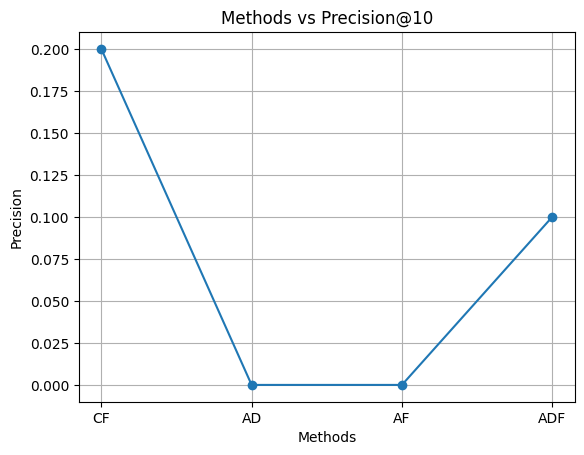

In [65]:
# @title Visualizing Precision@10 trends for a user
import matplotlib.pyplot as plt

# Precision
plt.figure()
plt.plot(methods, precs, marker='o')
plt.title("Methods vs Precision@10")
plt.xlabel("Methods")
plt.ylabel("Precision")
plt.grid()
plt.show()

### ILD

In [38]:
from itertools import combinations

def ild_score(recommended_items, news_cluster_map):

    if len(recommended_items) < 2:
        return 0

    pairs = list(combinations(recommended_items, 2))

    dissimilarities = []

    for item1, item2 in pairs:
        c1 = news_cluster_map.get(item1, -1)
        c2 = news_cluster_map.get(item2, -1)

        if c1 == c2:
            dissimilarities.append(0)
        else:
            dissimilarities.append(1)

    return sum(dissimilarities) / len(dissimilarities)

In [66]:
ild_results = {}
ild_results["CF"] = ild_score(recs, news_cluster_map)
ild_results["AD"] = ild_score(recs_ad, news_cluster_map)
ild_results["AF"] = ild_score(recs_af, news_cluster_map)
ild_results["ADF"] = ild_score(recs_adf, news_cluster_map)

print("Intra-List Diversity Results:")
methods = []
ild_vals = []
for method, ild_val in ild_results.items():
    methods.append(method)
    ild_vals.append(ild_val)
    print(f"{method}: {ild_val}")

Intra-List Diversity Results:
CF: 0.2
AD: 0.8444444444444444
AF: 1.0
ADF: 0.9111111111111111


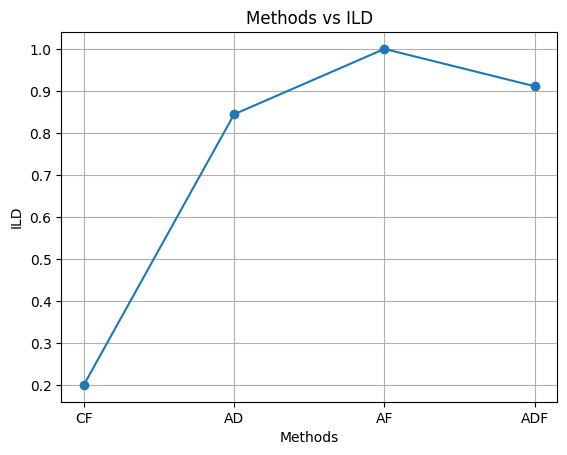

In [67]:
# @title Visualizing ILD trends for a user
import matplotlib.pyplot as plt

# Precision
plt.figure()
plt.plot(methods, ild_vals, marker='o')
plt.title("Methods vs ILD")
plt.xlabel("Methods")
plt.ylabel("ILD")
plt.grid()
plt.show()

### S-Recall@10

In [40]:
def s_recall_at_k(recommended_items, ground_truth, k=10):

    recommended_k = recommended_items[:k]

    for item in recommended_k:
        if item in ground_truth:
            return 1  # success

    return 0  # failure

In [68]:
s_recall_results = {}
s_recall_results["CF"] = s_recall_at_k(recs, ground_truth, k=10)
s_recall_results["AD"] = s_recall_at_k(recs_ad, ground_truth, k=10)
s_recall_results["AF"] = s_recall_at_k(recs_af, ground_truth, k=10)
s_recall_results["ADF"] = s_recall_at_k(recs_adf, ground_truth, k=10)

print("S-Recall@10 Results:")
methods = []
srecs = []
for method, srec in s_recall_results.items():
    methods.append(method)
    srecs.append(srec)
    print(f"{method}: {srec}")

S-Recall@10 Results:
CF: 1
AD: 0
AF: 0
ADF: 1


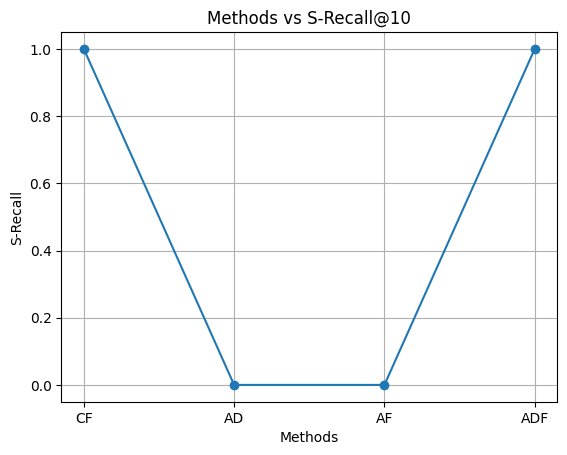

In [69]:
# @title Visualizing S-Recall@10 trends for a user
import matplotlib.pyplot as plt

# Precision
plt.figure()
plt.plot(methods, srecs, marker='o')
plt.title("Methods vs S-Recall@10")
plt.xlabel("Methods")
plt.ylabel("S-Recall")
plt.grid()
plt.show()

### CHC Calibration

In [42]:
news_category_map = news_df.set_index('news_id')['category'].to_dict()

In [43]:
from collections import defaultdict, Counter

def build_user_history_distribution(user_clicks, news_category_map):

    user_hist_dist = {}

    for user, clicked_items in user_clicks.items():

        categories = []

        for item in clicked_items:

            if item in news_category_map:
                categories.append(news_category_map[item])

        if len(categories) == 0:
            continue

        counts = Counter(categories)
        total = sum(counts.values())

        probs = {
            cat: counts[cat] / total
            for cat in counts
        }

        user_hist_dist[user] = probs

    return user_hist_dist

In [44]:
def chc_score(recommended_items,
              historical_distribution,
              news_category_map):

    if len(recommended_items) == 0:
        return 0

    # recommendation category distribution
    rec_categories = []

    for item in recommended_items:

        if item in news_category_map:
            rec_categories.append(news_category_map[item])

    if len(rec_categories) == 0:
        return 0

    rec_counts = Counter(rec_categories)
    total_rec = sum(rec_counts.values())

    rec_distribution = {
        cat: rec_counts[cat] / total_rec
        for cat in rec_counts
    }

    # all categories involved
    all_categories = set(historical_distribution.keys()) | set(rec_distribution.keys())

    distance = 0

    for cat in all_categories:

        p_hist = historical_distribution.get(cat, 0)
        p_rec = rec_distribution.get(cat, 0)

        distance += abs(p_rec - p_hist)

    return 1 - 0.5 * distance

In [56]:
historical_distribution = build_user_history_distribution(
    user_clicks,
    news_category_map
)

In [57]:
user_hist_dist = historical_distribution[user_id]

In [70]:
chc_results = {}
chc_results["CF"] = chc_score(recs, user_hist_dist, news_category_map)
chc_results["AD"] = chc_score(recs_ad, user_hist_dist, news_category_map)
chc_results["AF"] = chc_score(recs_af, user_hist_dist, news_category_map)
chc_results["ADF"] = chc_score(recs_adf, user_hist_dist, news_category_map)

print("CHC Calibration Results:")
methods = []
chcs = []
for method, chc in chc_results.items():
    methods.append(method)
    chcs.append(chc)
    print(f"{method}: {chc}")

CHC Calibration Results:
CF: 0.4
AD: 0.44285714285714284
AF: 0.47142857142857153
ADF: 0.5714285714285715


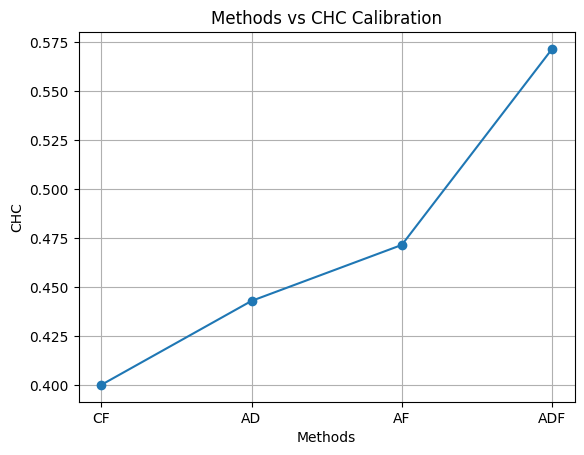

In [73]:
# @title Visualizing CHC Calibration trends for a user
import matplotlib.pyplot as plt

# Precision
plt.figure()
plt.plot(methods, chcs, marker='o')
plt.title("Methods vs CHC Calibration")
plt.xlabel("Methods")
plt.ylabel("CHC")
plt.grid()
plt.show()

### HCH Calibration

In [53]:
news_hierarchy_map = news_df[['news_id', 'category', 'subcategory']] \
    .set_index('news_id') \
    .to_dict(orient='index')

In [54]:
from collections import Counter

def build_user_hierarchical_distribution(user_clicks,
                                         news_hierarchy_map):

    user_hist_dist = {}

    for user, clicked_items in user_clicks.items():

        category_list = []
        subcategory_list = []

        for item in clicked_items:

            if item not in news_hierarchy_map:
                continue

            category_list.append(
                news_hierarchy_map[item]["category"]
            )

            subcategory_list.append(
                news_hierarchy_map[item]["subcategory"]
            )

        if len(category_list) == 0:
            continue

        # category distribution
        cat_counts = Counter(category_list)
        total_cat = sum(cat_counts.values())

        cat_probs = {
            c: cat_counts[c] / total_cat
            for c in cat_counts
        }

        # subcategory distribution
        subcat_counts = Counter(subcategory_list)
        total_subcat = sum(subcat_counts.values())

        subcat_probs = {
            c: subcat_counts[c] / total_subcat
            for c in subcat_counts
        }

        user_hist_dist[user] = {
            "category": cat_probs,
            "subcategory": subcat_probs
        }

    return user_hist_dist

In [55]:
def hch_score(recommended_items,
              historical_distribution,
              news_hierarchy_map):

    if len(recommended_items) == 0:
        return 0

    levels = ["category", "subcategory"]

    total_distance = 0

    for level in levels:

        rec_values = []

        for item in recommended_items:

            if item not in news_hierarchy_map:
                continue

            rec_values.append(
                news_hierarchy_map[item][level]
            )

        if len(rec_values) == 0:
            continue

        # recommendation distribution
        rec_counts = Counter(rec_values)
        total_rec = sum(rec_counts.values())

        rec_distribution = {
            c: rec_counts[c] / total_rec
            for c in rec_counts
        }

        # historical distribution
        hist_distribution = historical_distribution[level]

        all_keys = (
            set(rec_distribution.keys()) |
            set(hist_distribution.keys())
        )

        level_distance = 0

        for key in all_keys:

            p_rec = rec_distribution.get(key, 0)
            p_hist = hist_distribution.get(key, 0)

            level_distance += abs(p_rec - p_hist)

        total_distance += level_distance

    return 1 - 0.5 * total_distance / len(levels)

In [60]:
user_hierarchical_distribution = build_user_hierarchical_distribution(
    user_clicks,
    news_hierarchy_map
)

In [61]:
user_hier_dist = user_hierarchical_distribution[user_id]

In [72]:
hch_results = {}
hch_results["CF"] = hch_score(recs, user_hier_dist, news_hierarchy_map)
hch_results["AD"] = hch_score(recs_ad, user_hier_dist, news_hierarchy_map)
hch_results["AF"] = hch_score(recs_af, user_hier_dist, news_hierarchy_map)
hch_results["ADF"] = hch_score(recs_adf, user_hier_dist, news_hierarchy_map)

print("CHC Calibration Results:")
methods = []
hchs = []
for method, hch in hch_results.items():
    methods.append(method)
    hchs.append(hch)
    print(f"{method}: {hch}")

CHC Calibration Results:
CF: 0.2857142857142857
AD: 0.34285714285714286
AF: 0.33571428571428574
ADF: 0.4214285714285715


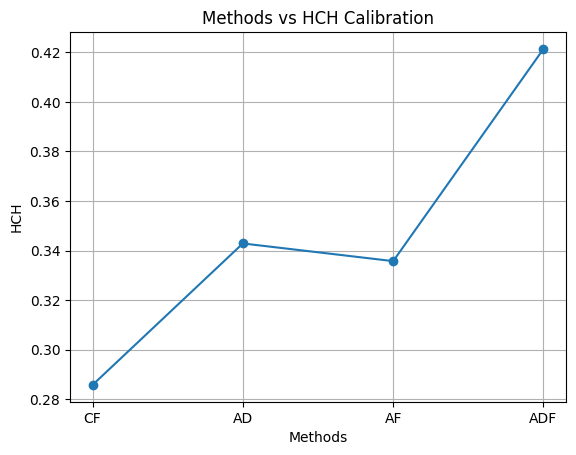

In [74]:
# @title Visualizing HCH Calibration trends for a user
import matplotlib.pyplot as plt

# Precision
plt.figure()
plt.plot(methods, hchs, marker='o')
plt.title("Methods vs HCH Calibration")
plt.xlabel("Methods")
plt.ylabel("HCH")
plt.grid()
plt.show()